In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys
from itertools import combinations

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import torch

sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RUNS         = 5
NUM_EPOCHS     = 500
VALIDATE_EVERY = 50
PATIENCE       = 20
HOLDOUT_FRAC   = 0.20       # fraction of combo perts to hold out
HOLDOUT_SEED   = 42         # fixed seed for reproducible hold-out split
SYN_Q_THRESH   = 0.05       # FDR threshold for significant synergies
RESULTS_DIR    = 'results/reproducibility_norman'

SHERLOCK_KWARGS = dict(
    ce_lambda=1e-1,
    l0_lambda=5.,
    rank=6,
    shuffle=True,
    num_workers=0,
)

os.makedirs(f'{RESULTS_DIR}/figures', exist_ok=True)
print(f'Device: {DEVICE}  Results: {RESULTS_DIR}')

Device: cuda  Results: results/reproducibility_norman


## Load Norman 2019 data

Norman et al. 2019 (CRISPRa screen) — 105 single and 131 double perturbations in K562 cells.

In [4]:
data = sc.read_h5ad('../../datasets/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f'Cells: {data.n_obs}   Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}')

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering

Keep top 2000 HVGs (seurat_v3) union with all perturbation target genes.

In [5]:
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)
pert_mask = data.var_names.isin(pert_genes)
keep_mask = data.var['highly_variable'] | pert_mask
data = data[:, keep_mask].copy()

n_hvg       = data.var['highly_variable'].sum()
n_pert_only = (pert_mask[keep_mask] & ~data.var['highly_variable']).sum()
print(f'Kept {data.n_vars} genes  ({n_hvg} HVG + {n_pert_only} pert-only not in HVG)')

Kept 2040 genes  (2000 HVG + 40 pert-only not in HVG)


## Treatment effects

Ground-truth per-perturbation mean effects (log2-CPM vs NTC). Computed on the **full** dataset including held-out combos — used as the ATE reference throughout.

In [6]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f'treat_effect: {te.n_obs} perturbations × {te.n_vars} genes')
print(f'  single: {sum("+" not in p and p != NTC for p in te.obs_names)}   combo: {sum("+" in p for p in te.obs_names)}')

100%|██████████| 236/236 [00:03<00:00, 64.79it/s]

treat_effect: 236 perturbations × 2040 genes
  single: 105   combo: 131


## Hold-out split (20% of combo perturbations)

A fixed random 20% of combo perts are held out from training across all runs.  
The model sees only single perts + the remaining 80% of combos during training.  
ATE on held-out combos tests generalisation of combinatorial predictions.

In [7]:
rng        = np.random.default_rng(HOLDOUT_SEED)
combo_arr  = np.array(sorted(combo_perts))
n_holdout  = max(1, int(np.round(len(combo_arr) * HOLDOUT_FRAC)))
holdout_idx    = rng.choice(len(combo_arr), size=n_holdout, replace=False)
holdout_combos = set(combo_arr[holdout_idx])
train_combos   = set(combo_arr) - holdout_combos

print(f'Total combo perts : {len(combo_perts)}')
print(f'Training combos   : {len(train_combos)}')
print(f'Hold-out combos   : {len(holdout_combos)}  ({len(holdout_combos)/len(combo_perts):.1%})')

# Training subset: NTC + all singles + 80% combos
train_mask = ~data.obs[p_key].isin(holdout_combos)
train_data = data[train_mask].copy()
print(f'Training cells    : {train_data.n_obs} / {data.n_obs}')

print(f'\nHeld-out combos:')
for c in sorted(holdout_combos):
    print(f'  {c}')

Total combo perts : 131
Training combos   : 105
Hold-out combos   : 26  (19.8%)
Training cells    : 103000 / 111255

Held-out combos:
  C3orf72+FOXL2
  CBFA2T3+FEV
  CBL+PTPN9
  CEBPA+CEBPB
  CEBPA+CEBPE
  CNN1+UBASH3B
  DUSP9+SNAI1
  ETS2+IGDCC3
  ETS2+IKZF3
  ETS2+MAP7D1
  FOSB+OSR2
  FOXA3+FOXF1
  FOXF1+HOXB9
  FOXL2+MEIS1
  FOXL2+ZNF318
  IGDCC3+PRTG
  IKZF3+MAPK1
  MAP2K3+MAP2K6
  MAPK1+PRTG
  PRTG+TGFBR2
  PTPN12+SAMD1
  PTPN12+UBASH3B
  RHOXF2+ZBTB25
  S1PR2+SGK1
  SNAI1+UBASH3B
  TBX2+TBX3


## Reproducibility loop

Train `N_RUNS` independent models (different random seeds) on the training subset.  
After each run:
- Compute ATE Pearson r on **held-out** combo perturbations (generalisation metric)
- Extract significant synergies (q < `SYN_Q_THRESH`) from the training combos


Run 1/5
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [20:56<00:00,  2.51s/it, ATE=0.6538, CE=4.6297, ELBO=1340.4287, KLw=1.00, R2_ntc=0.9241, R2_p=0.9316, acc=0.327, pi25=0.02, pi99=1.00, tau=0.300] 


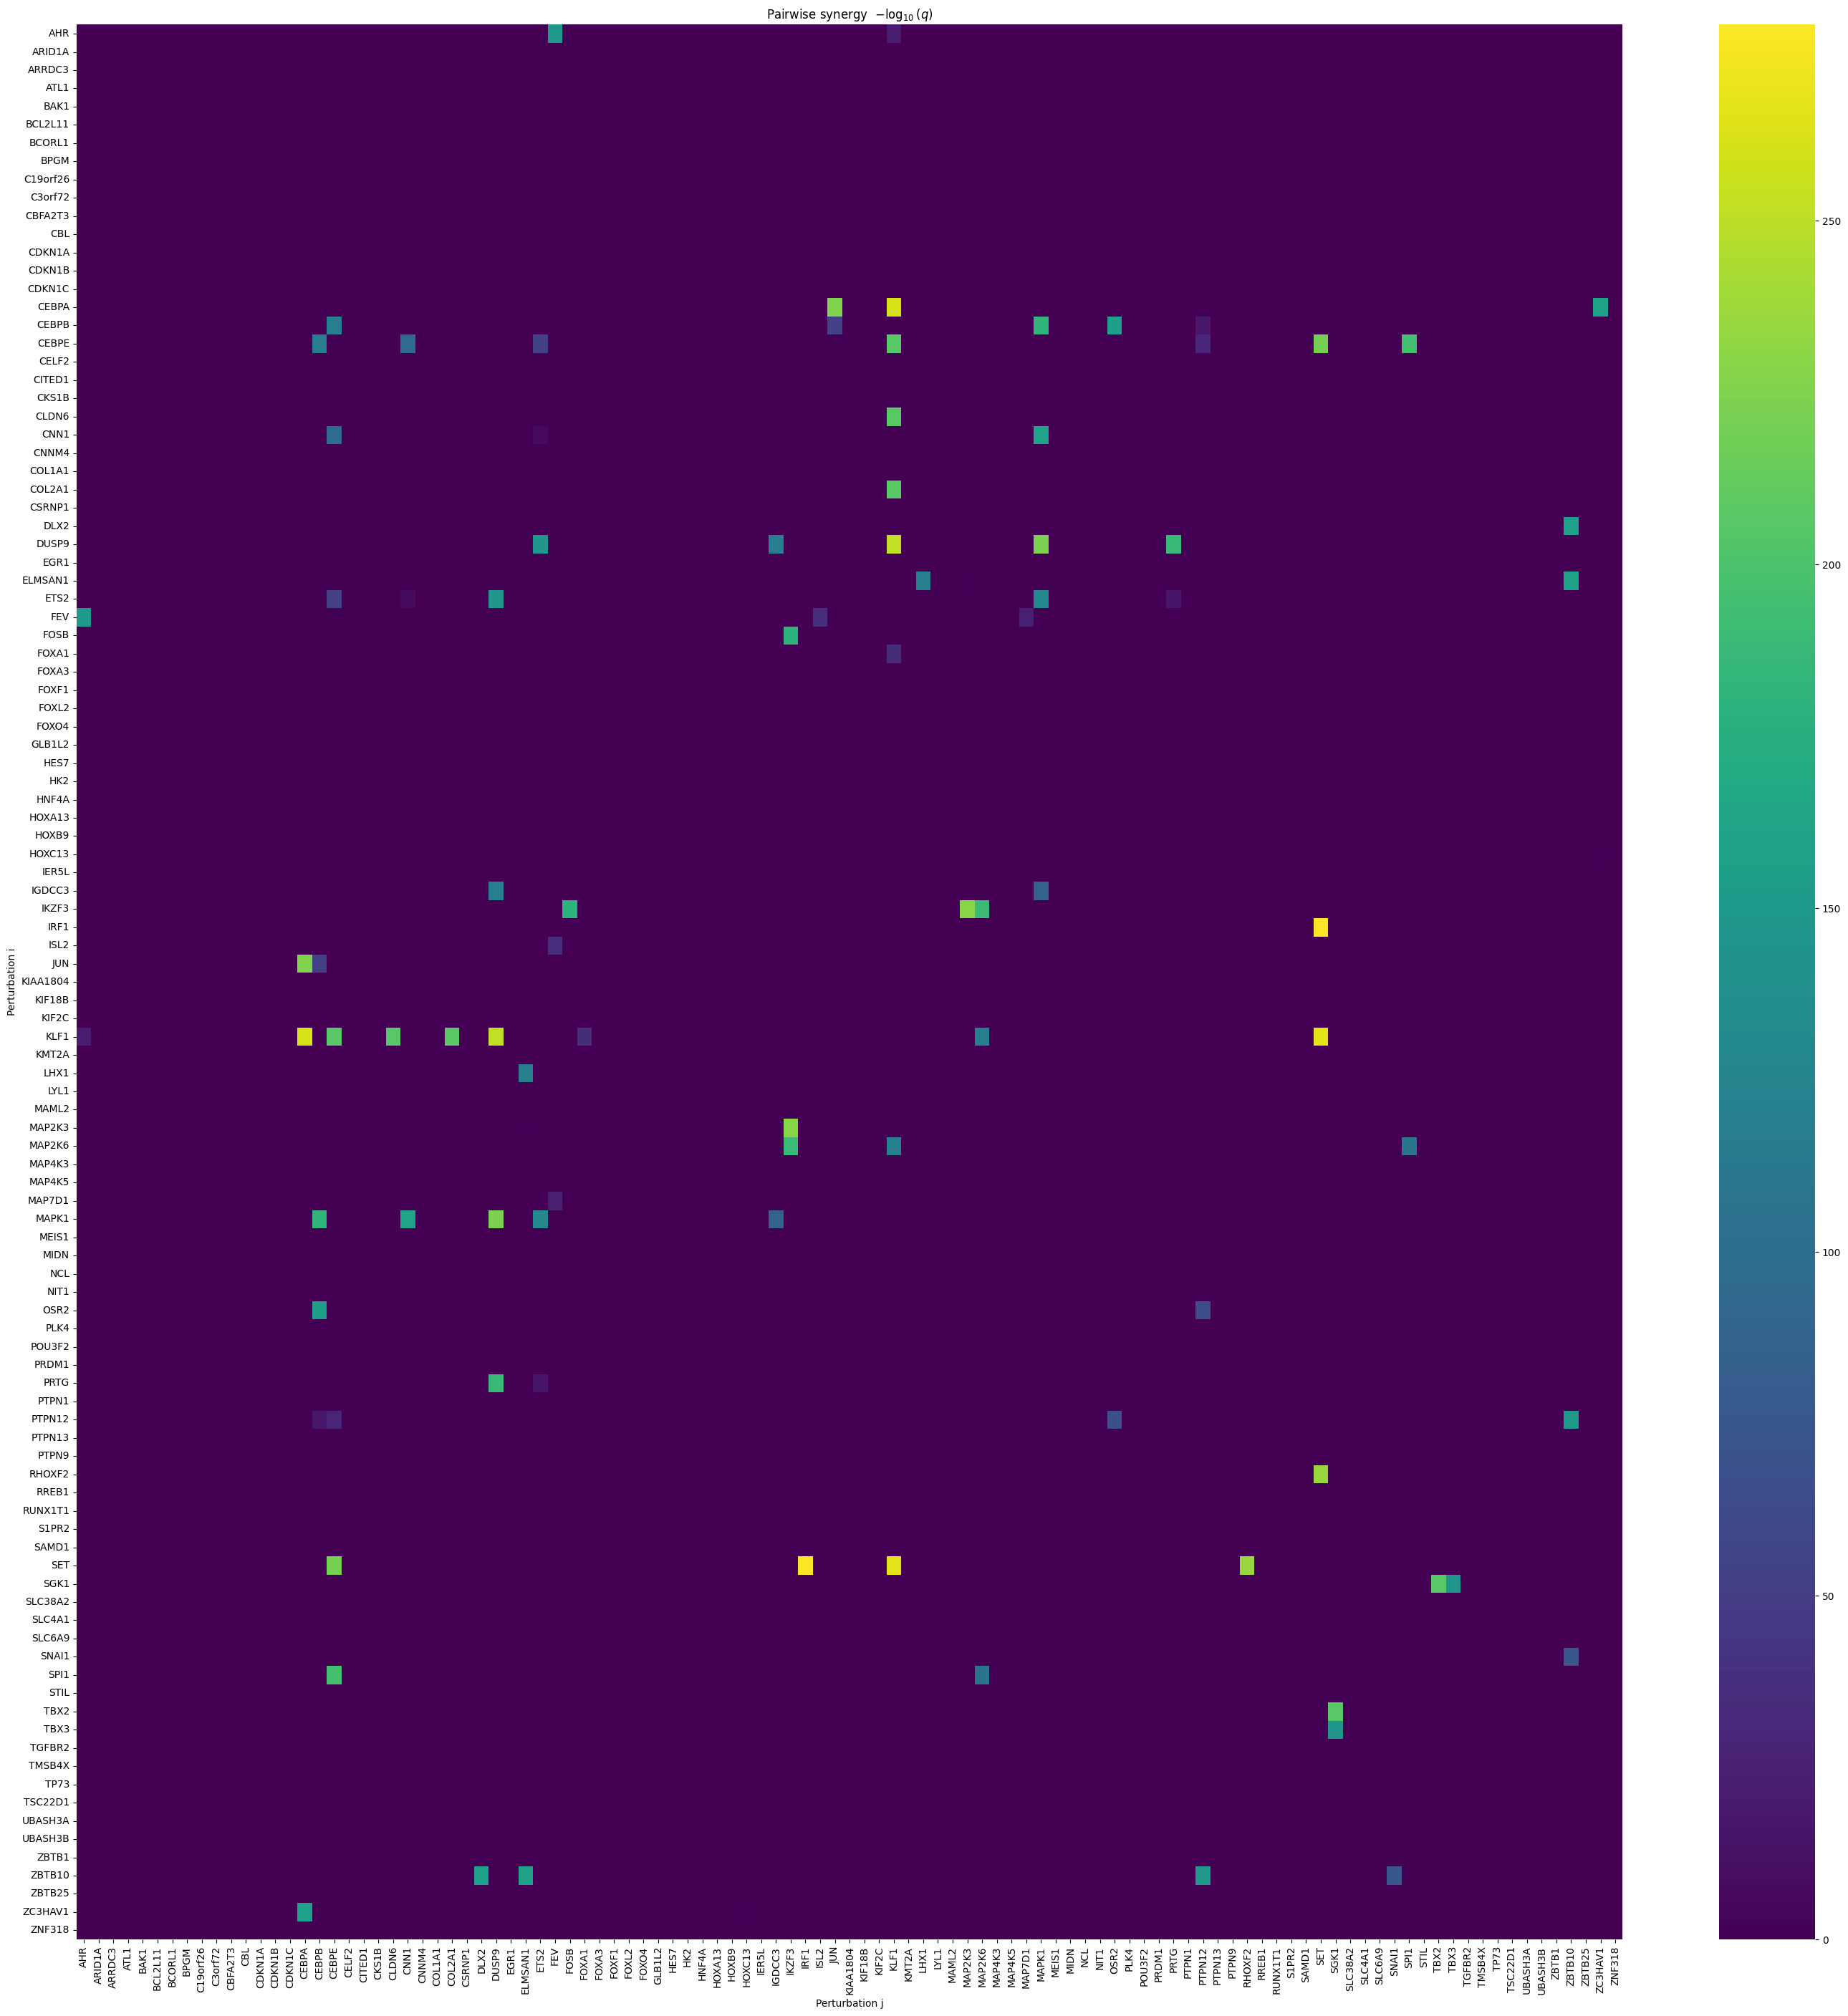

  ATE (all perts)    : 0.6491
  ATE (single perts) : 0.5841
  ATE (train combos) : 0.6846
  ATE (held-out)     : 0.6599  [n=26]
  Sig synergies      : 48 / 105  (q<0.05)

Run 2/5
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [20:45<00:00,  2.49s/it, ATE=0.6016, CE=4.6817, ELBO=1341.0945, KLw=1.00, R2_ntc=0.9297, R2_p=0.9302, acc=0.316, pi25=0.02, pi99=1.00, tau=0.300] 


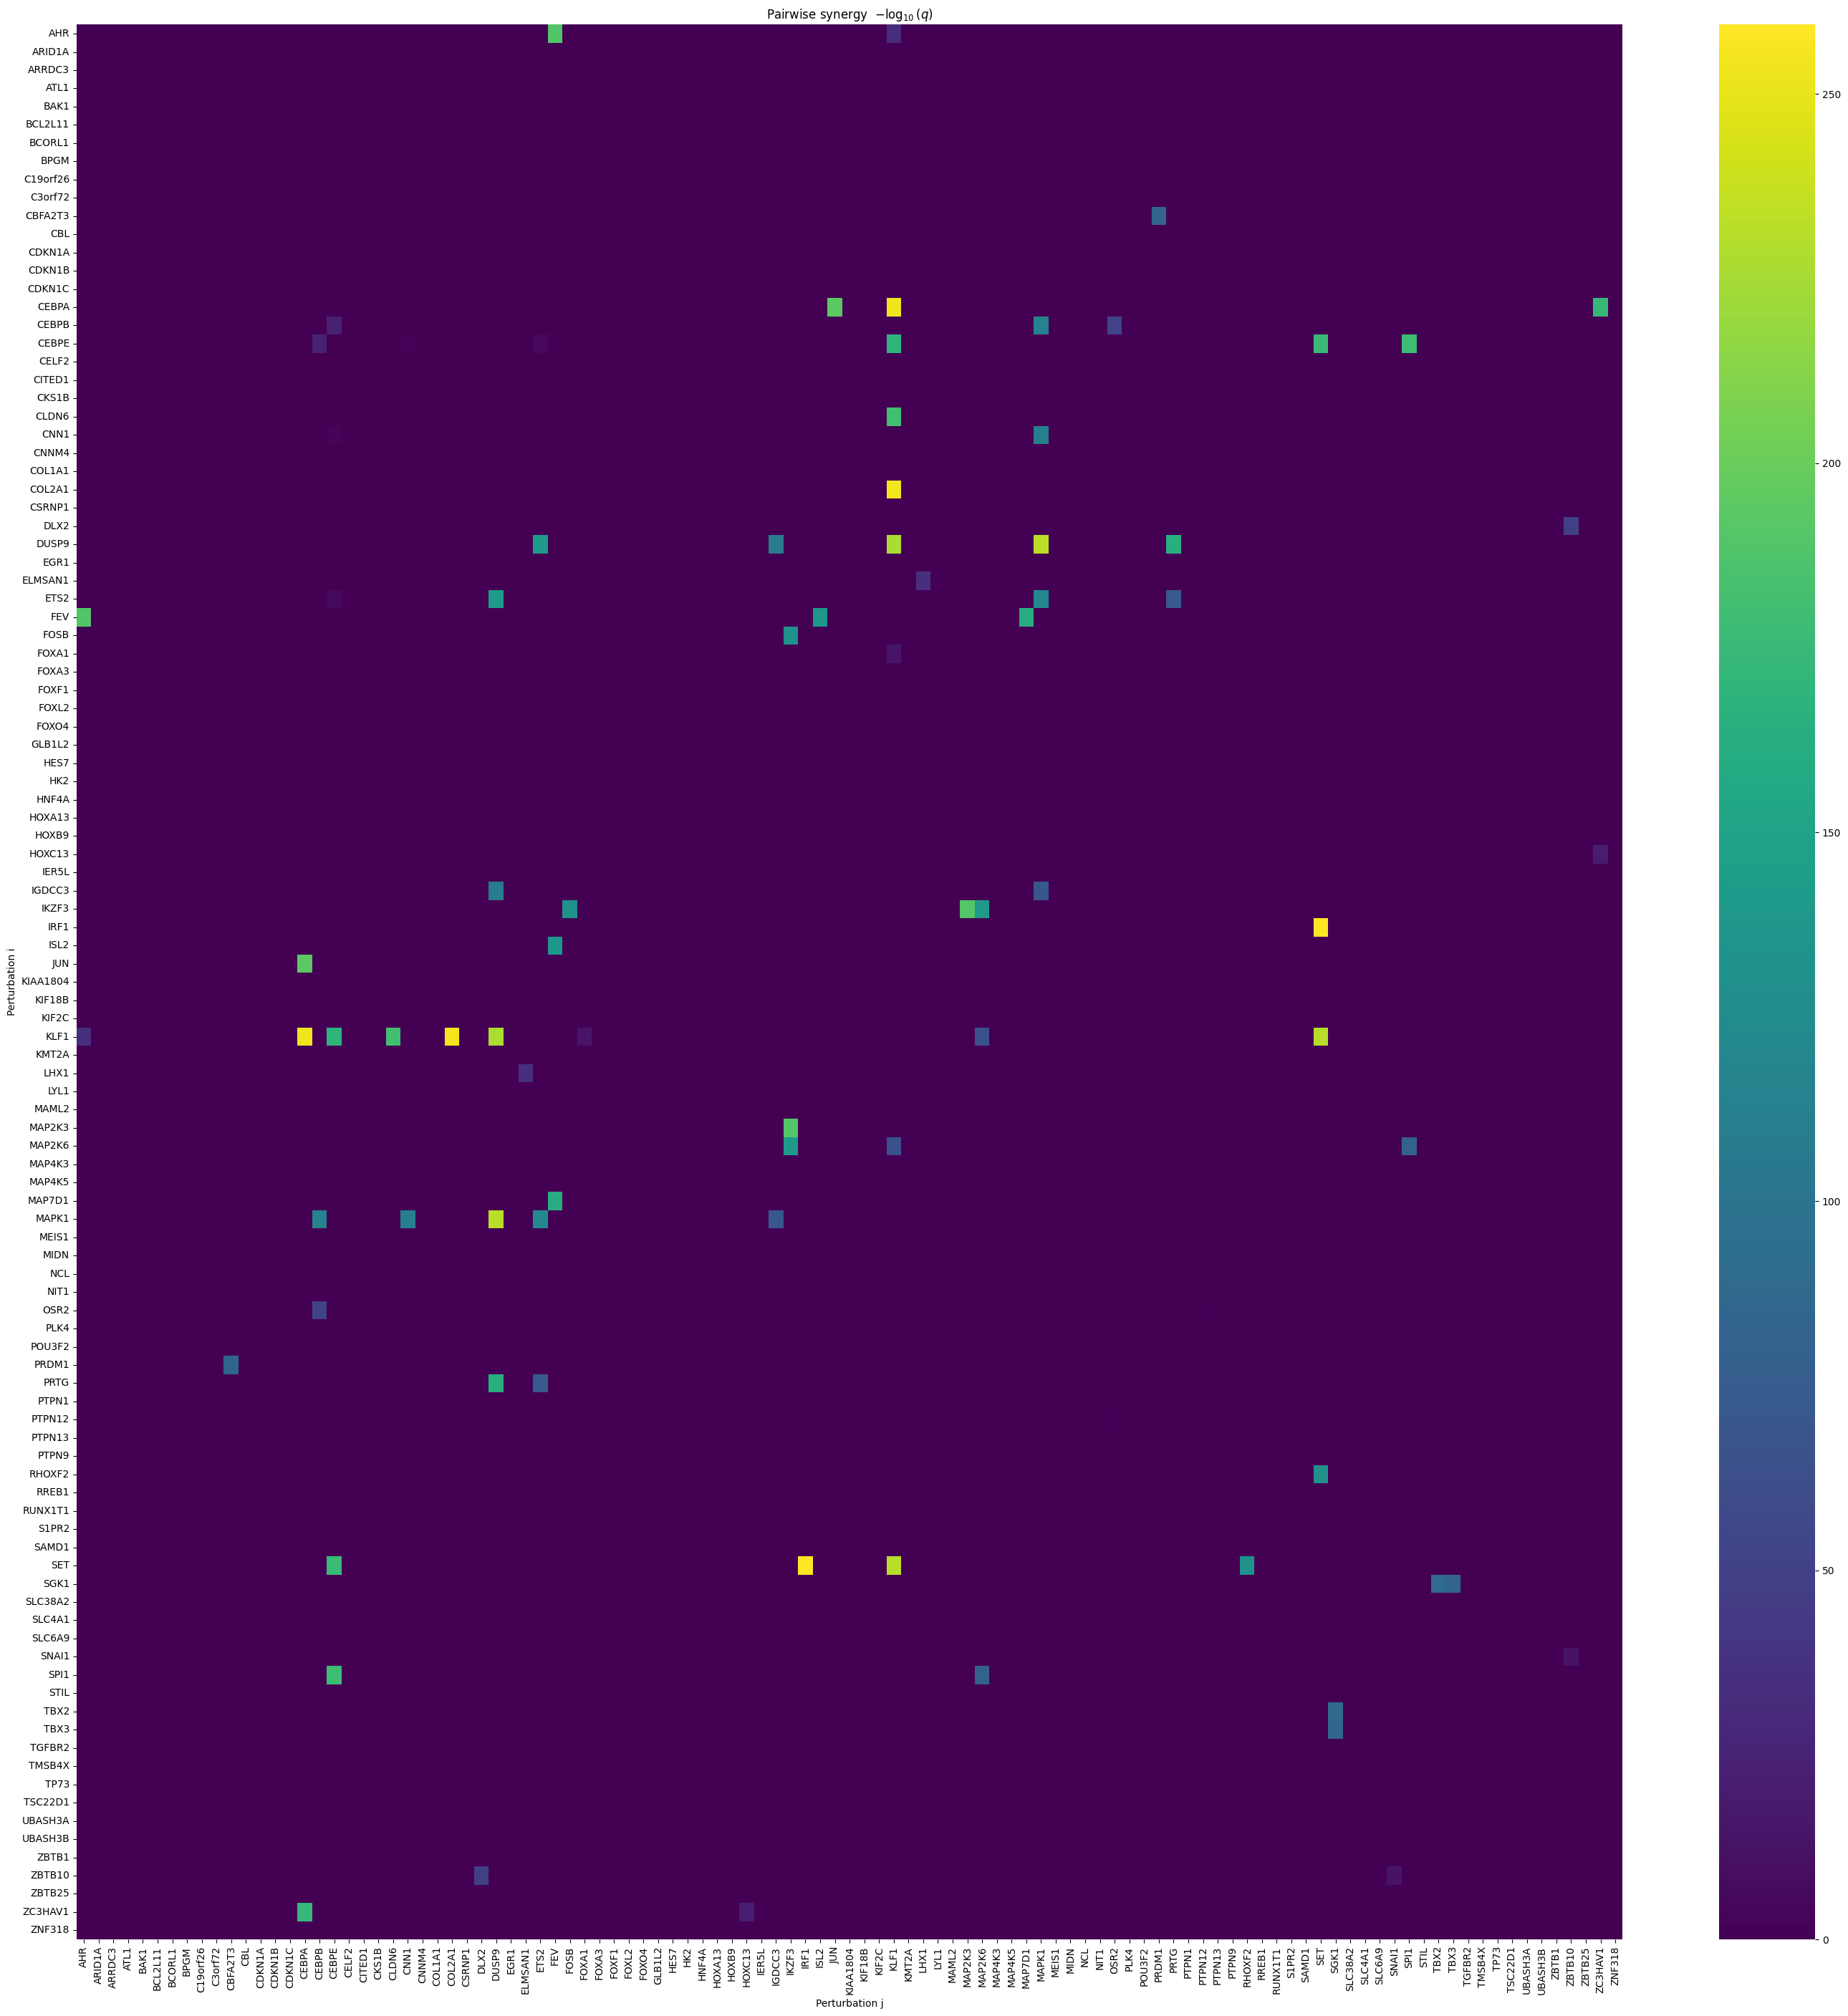

  ATE (all perts)    : 0.6005
  ATE (single perts) : 0.5308
  ATE (train combos) : 0.6319
  ATE (held-out)     : 0.6228  [n=26]
  Sig synergies      : 42 / 105  (q<0.05)

Run 3/5
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [20:21<00:00,  2.44s/it, ATE=0.6425, CE=4.6367, ELBO=1340.6982, KLw=1.00, R2_ntc=0.9235, R2_p=0.9297, acc=0.324, pi25=0.02, pi99=1.00, tau=0.300] 


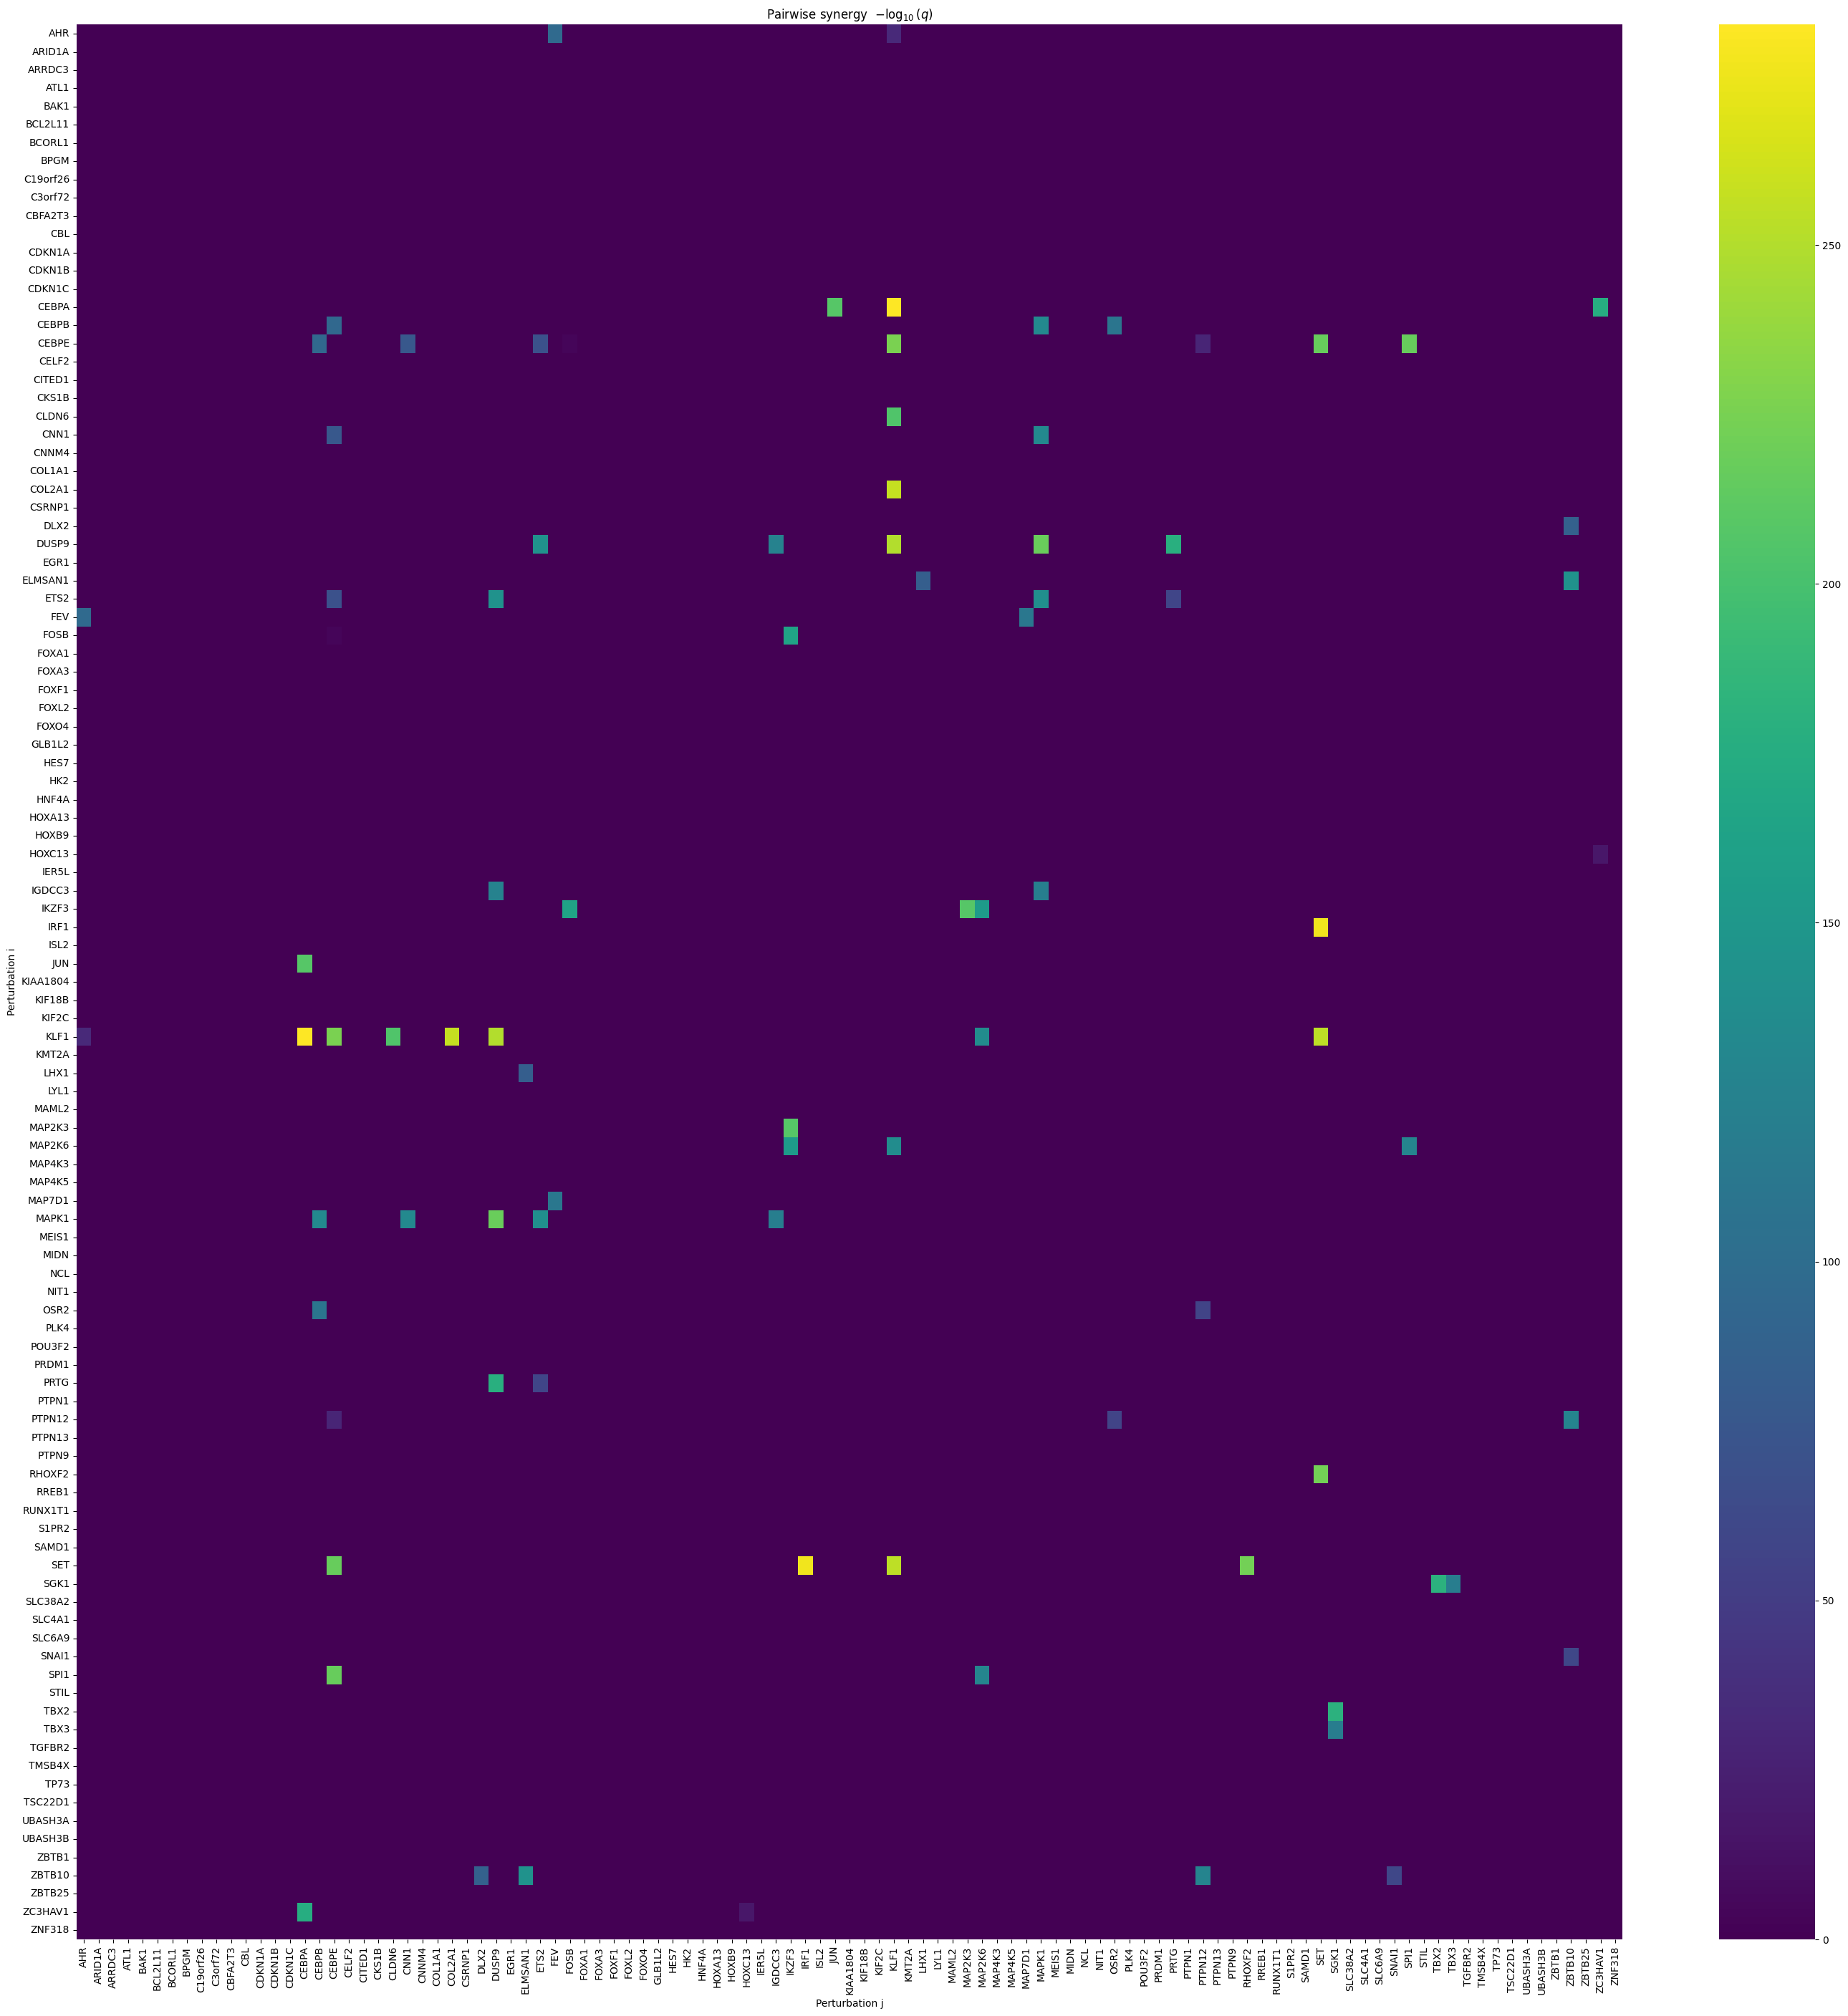

  ATE (all perts)    : 0.6401
  ATE (single perts) : 0.5756
  ATE (train combos) : 0.6719
  ATE (held-out)     : 0.6504  [n=26]
  Sig synergies      : 44 / 105  (q<0.05)

Run 4/5
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [20:44<00:00,  2.49s/it, ATE=0.6616, CE=4.7140, ELBO=1341.5223, KLw=1.00, R2_ntc=0.9259, R2_p=0.9258, acc=0.312, pi25=0.02, pi99=1.00, tau=0.300] 


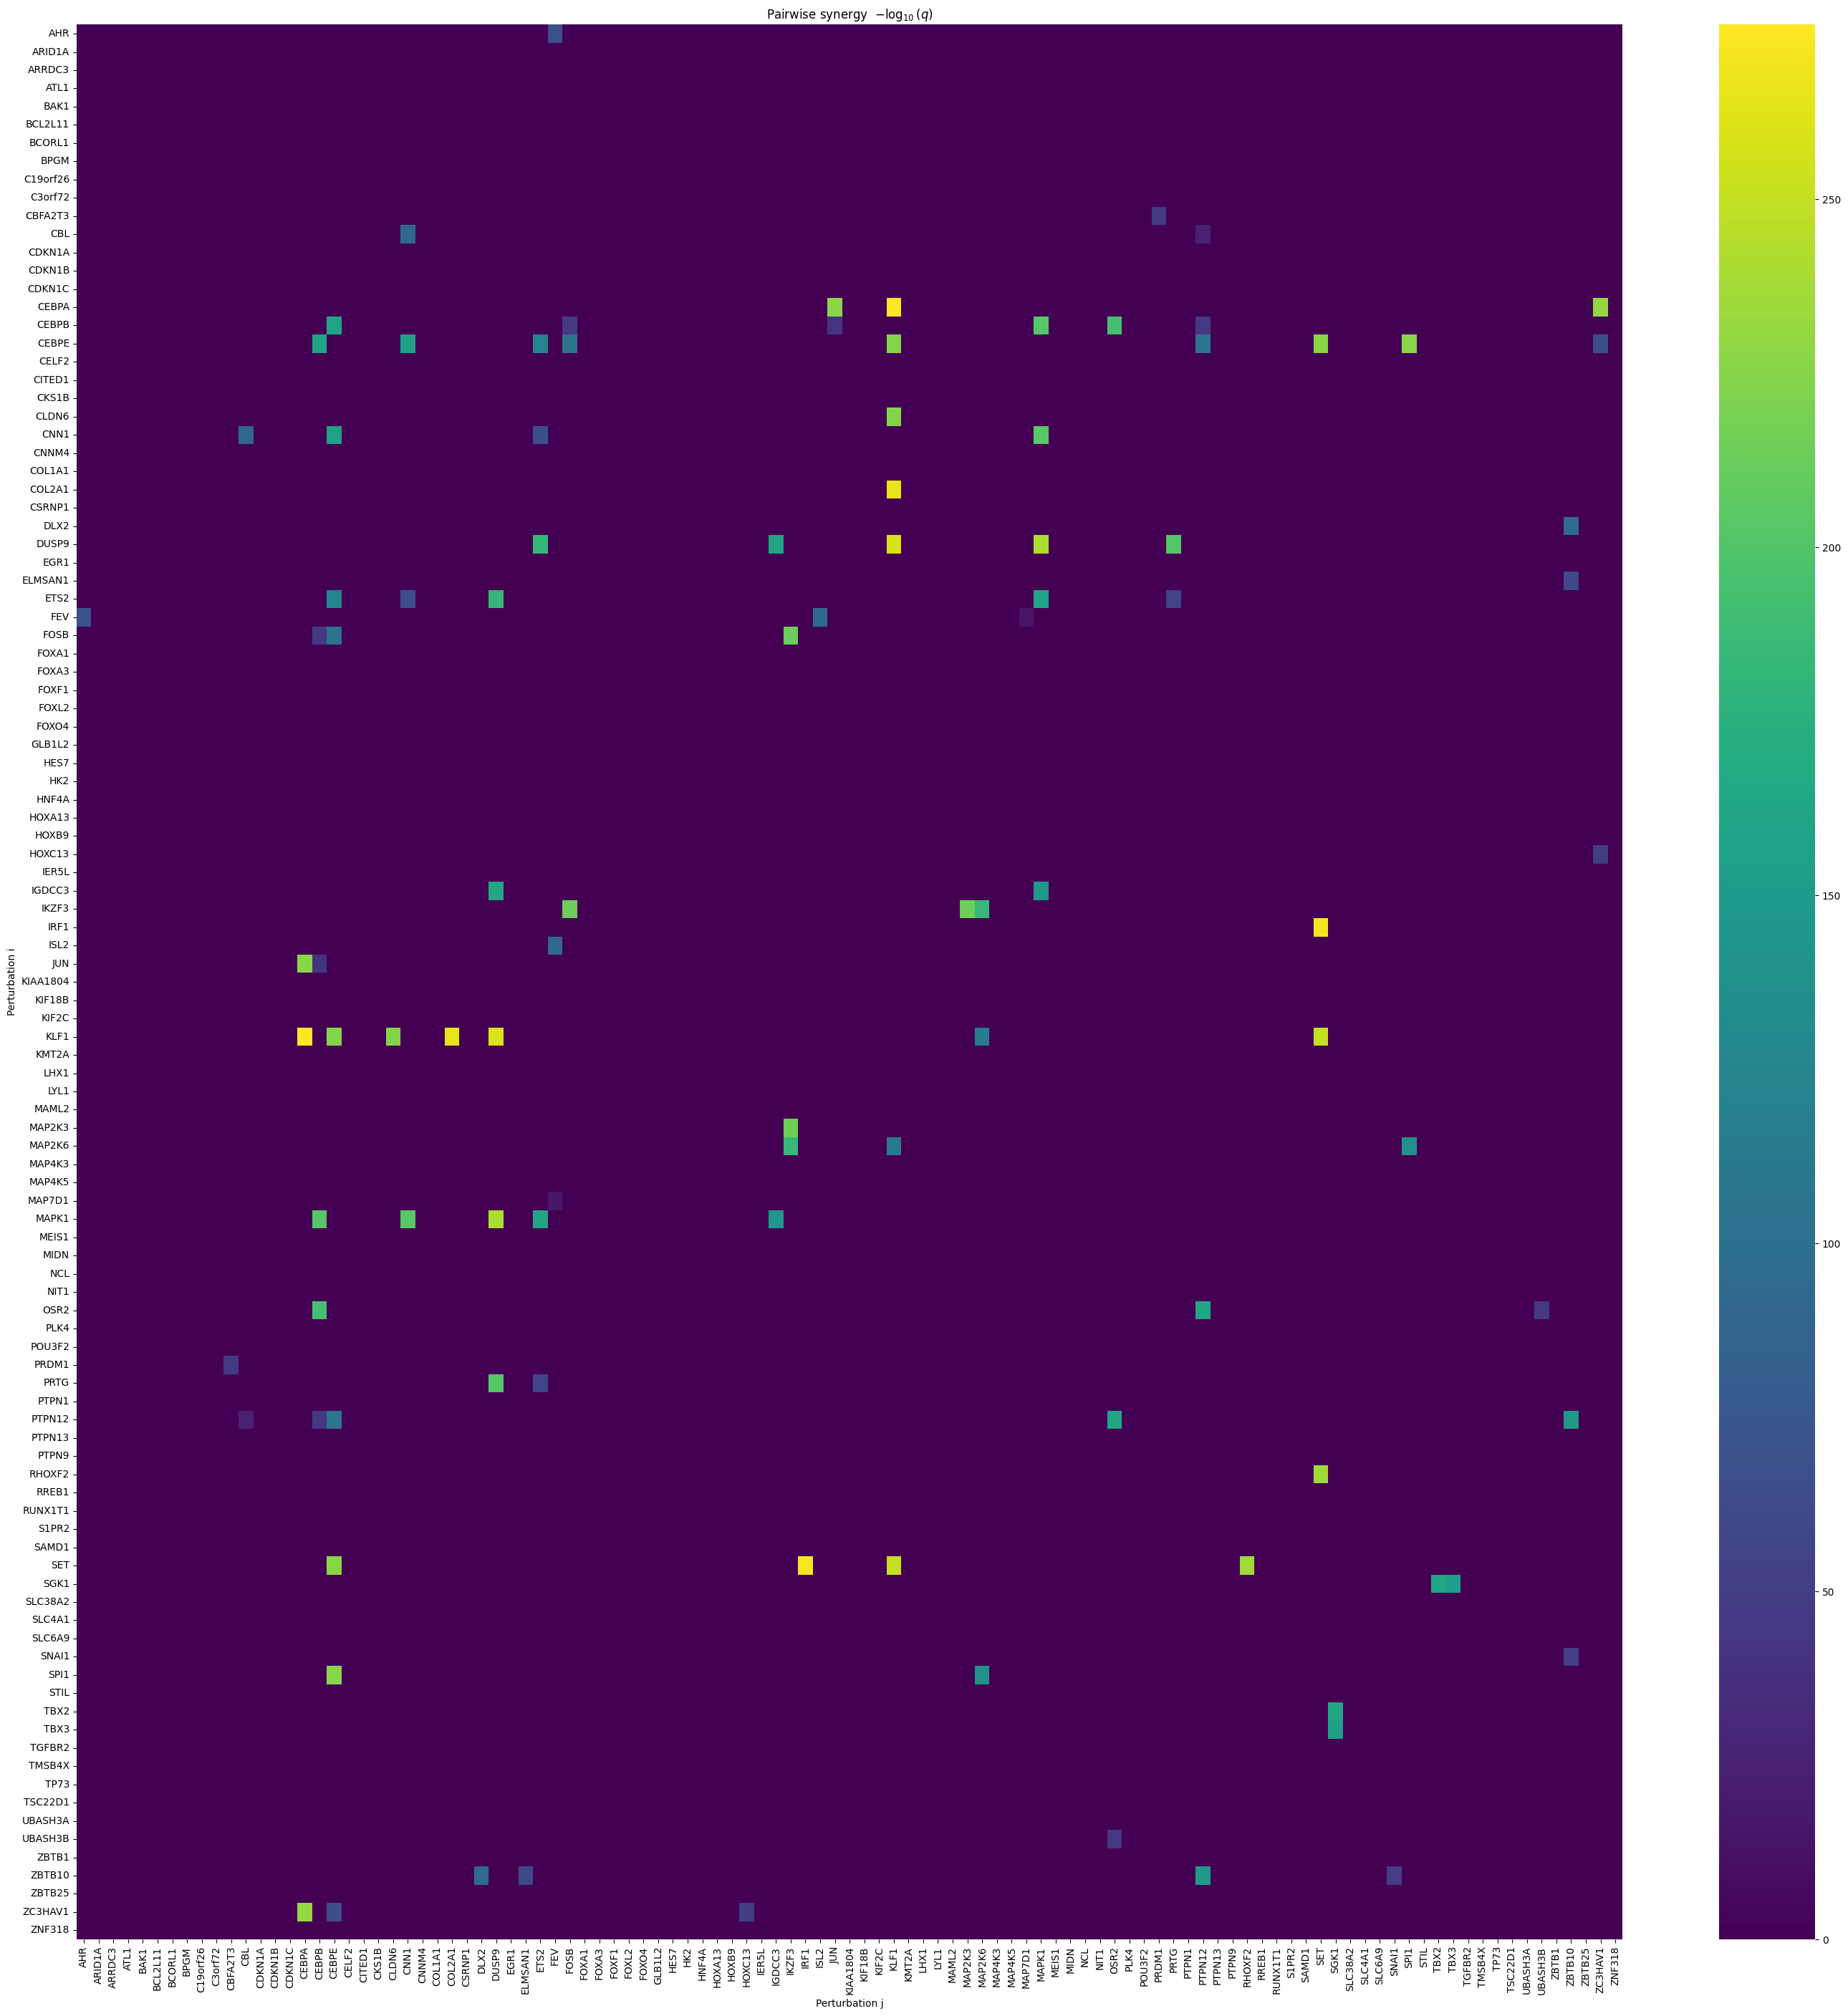

  ATE (all perts)    : 0.6551
  ATE (single perts) : 0.6176
  ATE (train combos) : 0.6865
  ATE (held-out)     : 0.6458  [n=26]
  Sig synergies      : 52 / 105  (q<0.05)

Run 5/5
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [20:40<00:00,  2.48s/it, ATE=0.6099, CE=4.6597, ELBO=1340.4989, KLw=1.00, R2_ntc=0.9278, R2_p=0.9304, acc=0.321, pi25=0.02, pi99=1.00, tau=0.300] 


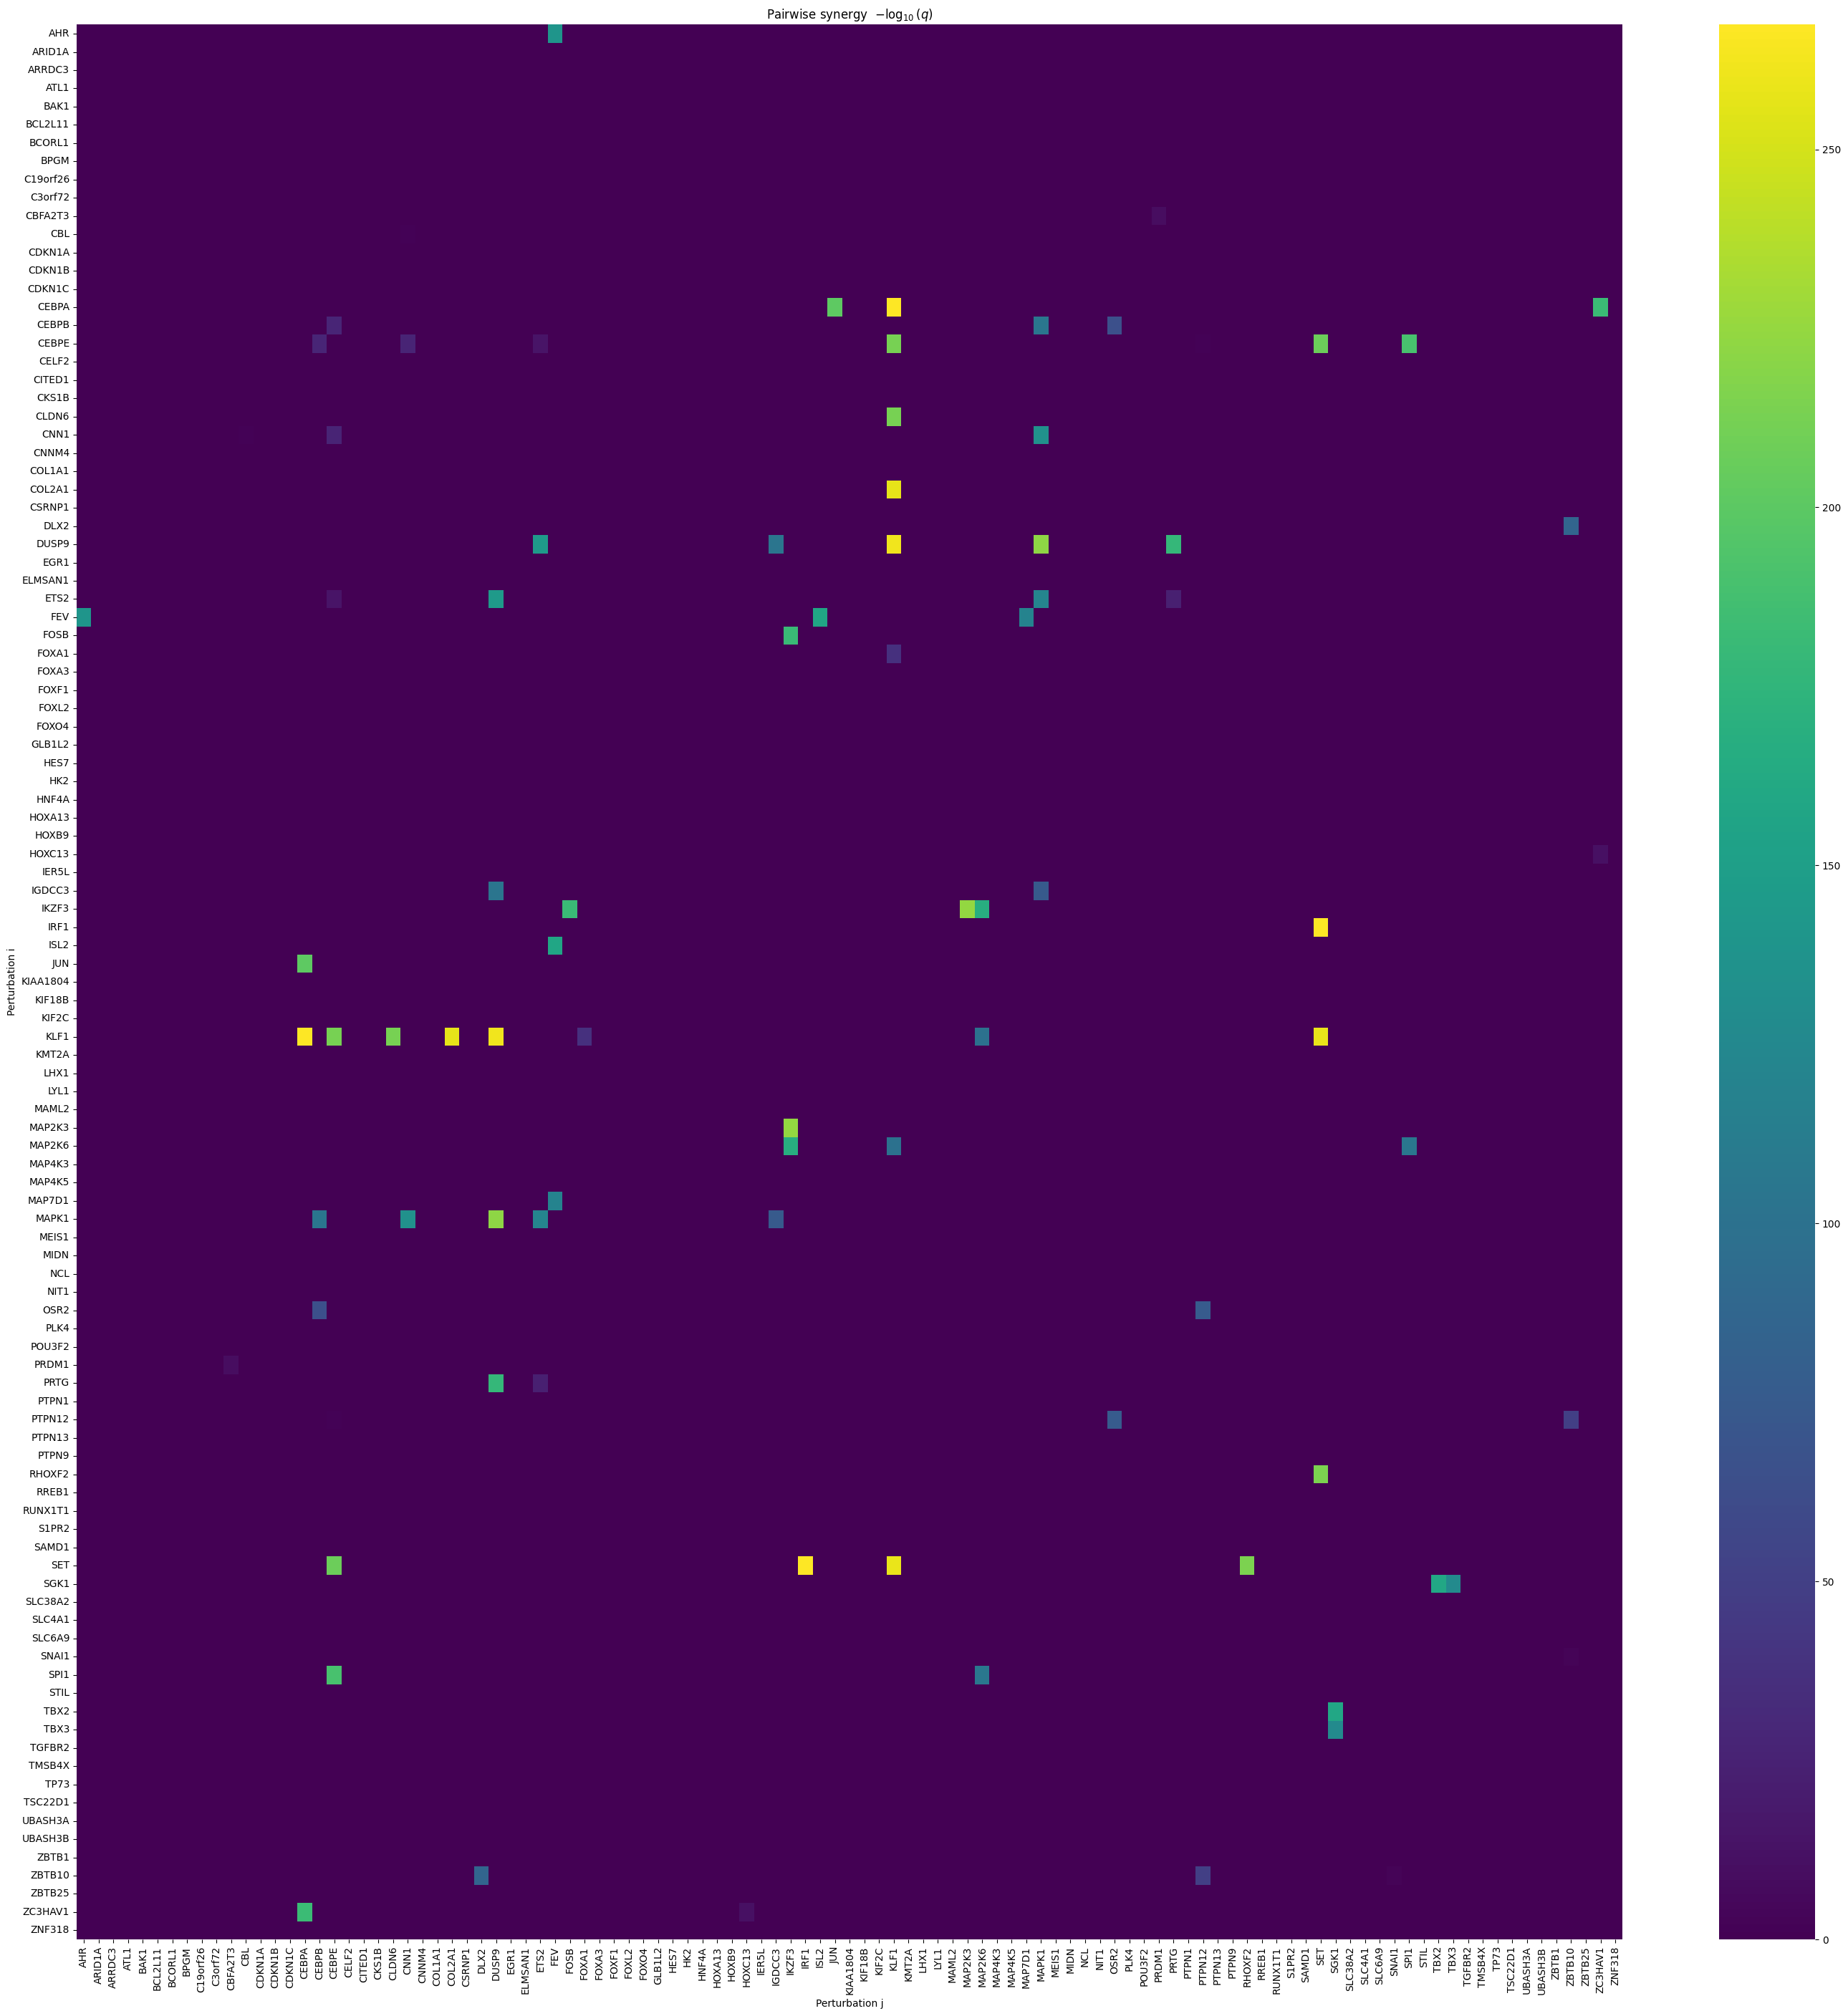

  ATE (all perts)    : 0.6081
  ATE (single perts) : 0.5419
  ATE (train combos) : 0.6397
  ATE (held-out)     : 0.6291  [n=26]
  Sig synergies      : 44 / 105  (q<0.05)

All runs complete.


In [8]:
run_results     = []
per_run_metrics = []

for run in range(N_RUNS):
    print(f"\n{'='*55}\nRun {run+1}/{N_RUNS}\n{'='*55}")

    results = slk.tl.run_single(
        train_data,
        model='vae',
        num_epochs=NUM_EPOCHS,
        validate_every=VALIDATE_EVERY,
        patience=PATIENCE,
        device=DEVICE,
        seed=run,
        combinatorial=True,
        use_synergy=True,
        **SHERLOCK_KWARGS,
    )
    model = results['model']

    # ---- Synergy detection on training combos ----
    slk.tl.eval_single(model, train_data, obsm_key='z', uns_key='results', device=DEVICE)
    syn_df = slk.pl.plot_synergy(train_data)
    plt.close('all')  # suppress inline plots during loop
    syn_df = syn_df.sort_values('qval').reset_index(drop=True)
    sig_syn = syn_df[syn_df['qval'] < SYN_Q_THRESH].copy()

    # Canonical (sorted-tuple) pair representation for set operations
    sig_syn_set = set(
        tuple(sorted([row['pert_i'], row['pert_j']]))
        for _, row in sig_syn.iterrows()
    )
    effect_sizes = {
        tuple(sorted([row['pert_i'], row['pert_j']])): row['effect_size']
        for _, row in syn_df.iterrows()
    }

    # ---- ATE on held-out combos ----
    try:
        ate = model.predict_counterfactual_effects(
            data,
            n_centroids=25,
            observed_effect=data.uns['treat_effect'],
        )
    except Exception as e:
        print(f'  Warning: ATE on full data failed ({e}), falling back to train_data')
        ate = model.predict_counterfactual_effects(
            train_data,
            n_centroids=25,
            observed_effect=data.uns['treat_effect'],
        )

    pred_df   = ate['predicted_df']
    obs_df    = ate['observed_df']
    ate_all_r = ate['corr']

    # ATE breakdown: single / training combos / held-out combos
    def _r(idx):
        idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
        if len(idx) < 2:
            return float('nan'), []
        x = pred_df.loc[idx].values.ravel()
        y = obs_df.loc[idx].values.ravel()
        v = np.isfinite(x) & np.isfinite(y)
        return (pearsonr(x[v], y[v])[0] if v.sum() > 2 else float('nan')), idx

    ate_single_r, _  = _r(single_perts)
    ate_train_r,  _  = _r(list(train_combos))
    ate_held_r, held_idx_found = _r(list(holdout_combos))

    held_pred = pred_df.loc[held_idx_found].copy() if held_idx_found else None

    run_results.append({
        'run':          run,
        'model':        model,
        'syn_df':       syn_df,
        'sig_syn_set':  sig_syn_set,
        'n_sig':        len(sig_syn),
        'effect_sizes': effect_sizes,
        'ate_all_r':    ate_all_r,
        'ate_single_r': ate_single_r,
        'ate_train_r':  ate_train_r,
        'ate_held_r':   ate_held_r,
        'held_pred':    held_pred,   # (held-out combos) × genes DataFrame
    })

    per_run_metrics.append({
        'run':          run + 1,
        'ate_all_r':    ate_all_r,
        'ate_single_r': ate_single_r,
        'ate_train_r':  ate_train_r,
        'ate_held_r':   ate_held_r,
        'n_sig_syn':    len(sig_syn),
        'n_tested_syn': len(syn_df),
    })

    print(f'  ATE (all perts)    : {ate_all_r:.4f}')
    print(f'  ATE (single perts) : {ate_single_r:.4f}')
    print(f'  ATE (train combos) : {ate_train_r:.4f}')
    print(f'  ATE (held-out)     : {ate_held_r:.4f}  [n={len(held_idx_found)}]')
    print(f'  Sig synergies      : {len(sig_syn)} / {len(syn_df)}  (q<{SYN_Q_THRESH})')

print('\nAll runs complete.')

## Per-run metrics

In [9]:
metrics_df = pd.DataFrame(per_run_metrics).set_index('run')
print(metrics_df.round(4).to_string())
print('\nMean ± Std:')
for col in metrics_df.columns:
    v = pd.to_numeric(metrics_df[col], errors='coerce').dropna().values
    if len(v):
        print(f'  {col:22s}: {np.mean(v):.4f} ± {np.std(v):.4f}')
    else:
        print(f'  {col:22s}: N/A')

     ate_all_r  ate_single_r  ate_train_r  ate_held_r  n_sig_syn  n_tested_syn
run                                                                           
1       0.6491        0.5841       0.6846      0.6599         48           105
2       0.6005        0.5308       0.6319      0.6228         42           105
3       0.6401        0.5756       0.6719      0.6504         44           105
4       0.6551        0.6176       0.6865      0.6458         52           105
5       0.6081        0.5419       0.6397      0.6291         44           105

Mean ± Std:
  ate_all_r             : 0.6306 ± 0.0221
  ate_single_r          : 0.5700 ± 0.0310
  ate_train_r           : 0.6629 ± 0.0228
  ate_held_r            : 0.6416 ± 0.0137
  n_sig_syn             : 46.0000 ± 3.5777
  n_tested_syn          : 105.0000 ± 0.0000


## Significant synergy overlap across runs

For each pair of runs, compute:
1. **Jaccard similarity** of the sets of significant synergy pairs (q < threshold).
2. **Pearson r of effect sizes** over all tested pairs shared between runs.

In [10]:
pairs = list(combinations(range(N_RUNS), 2))

jaccard_syn  = []
effect_corrs = []
ate_pred_corrs = []

for i, j in pairs:
    ri, rj = run_results[i], run_results[j]

    # --- Jaccard over significant synergy pairs ---
    si    = ri['sig_syn_set']
    sj    = rj['sig_syn_set']
    union = si | sj
    inter = si & sj
    jaccard_syn.append(len(inter) / len(union) if union else float('nan'))

    # --- Effect size Pearson r (shared tested pairs) ---
    ei     = ri['effect_sizes']
    ej     = rj['effect_sizes']
    shared = sorted(set(ei) & set(ej))
    if len(shared) > 2:
        vi = np.array([ei[p] for p in shared])
        vj = np.array([ej[p] for p in shared])
        r, _ = pearsonr(vi, vj)
        effect_corrs.append(r)
    else:
        effect_corrs.append(float('nan'))

    # --- Pairwise ATE prediction correlation (held-out combos) ---
    pi = ri['held_pred']
    pj = rj['held_pred']
    if pi is not None and pj is not None:
        common = pi.index.intersection(pj.index)
        if len(common) > 1:
            xi = pi.loc[common].values.ravel()
            xj = pj.loc[common].values.ravel()
            v  = np.isfinite(xi) & np.isfinite(xj)
            ate_pred_corrs.append(pearsonr(xi[v], xj[v])[0] if v.sum() > 2 else float('nan'))
        else:
            ate_pred_corrs.append(float('nan'))
    else:
        ate_pred_corrs.append(float('nan'))

pair_labels = [f'run{i+1}–run{j+1}' for i, j in pairs]

syn_summary = pd.DataFrame({
    'pair':              pair_labels,
    'jaccard_sig_syn':   jaccard_syn,
    'effect_size_corr':  effect_corrs,
    'ate_pred_corr':     ate_pred_corrs,
})
print(syn_summary.to_string(index=False))
print('\nMean ± Std:')
for col in ['jaccard_sig_syn', 'effect_size_corr', 'ate_pred_corr']:
    v = syn_summary[col].dropna().values
    if len(v):
        print(f'  {col:22s}: {np.mean(v):.4f} ± {np.std(v):.4f}')

     pair  jaccard_sig_syn  effect_size_corr  ate_pred_corr
run1–run2         0.800000          0.911103       0.958471
run1–run3         0.840000          0.957192       0.962021
run1–run4         0.785714          0.949688       0.961180
run1–run5         0.803922          0.961738       0.958493
run2–run3         0.829787          0.966114       0.959724
run2–run4         0.709091          0.936859       0.964530
run2–run5         0.869565          0.965005       0.958136
run3–run4         0.777778          0.967726       0.962720
run3–run5         0.833333          0.977414       0.962678
run4–run5         0.811321          0.959781       0.964140

Mean ± Std:
  jaccard_sig_syn       : 0.8061 ± 0.0414
  effect_size_corr      : 0.9553 ± 0.0180
  ate_pred_corr         : 0.9612 ± 0.0023


## Core synergies (present in all / most runs)

A synergy that appears significant in every run is a robust finding; one that appears in only one run may be noise.

In [11]:
all_sig_sets = [r['sig_syn_set'] for r in run_results]
core_syns    = set.intersection(*all_sig_sets) if all_sig_sets else set()
any_syns     = set.union(*all_sig_sets)         if all_sig_sets else set()

freq_syn = {pair: sum(pair in s for s in all_sig_sets) for pair in any_syns}
freq_df  = pd.DataFrame(
    [{'pair': f'{a}+{b}', 'n_runs': n, 'a': a, 'b': b} for (a, b), n in freq_syn.items()]
).sort_values(['n_runs', 'pair'], ascending=[False, True]).reset_index(drop=True)

print(f'Synergies significant in ALL {N_RUNS} runs : {len(core_syns)}')
print(f'Synergies significant in ≥{N_RUNS-1} runs  : {(freq_df["n_runs"] >= N_RUNS-1).sum()}')
print(f'Synergies significant in ANY run           : {len(any_syns)}')
print()
print(freq_df[['pair', 'n_runs']].to_string(index=False))

Synergies significant in ALL 5 runs : 36
Synergies significant in ≥4 runs  : 41
Synergies significant in ANY run           : 56

          pair  n_runs
       AHR+FEV       5
     CEBPA+JUN       5
    CEBPA+KLF1       5
 CEBPA+ZC3HAV1       5
   CEBPB+CEBPE       5
   CEBPB+MAPK1       5
    CEBPB+OSR2       5
    CEBPE+CNN1       5
    CEBPE+ETS2       5
    CEBPE+KLF1       5
     CEBPE+SET       5
    CEBPE+SPI1       5
    CLDN6+KLF1       5
    CNN1+MAPK1       5
   COL2A1+KLF1       5
   DLX2+ZBTB10       5
    DUSP9+ETS2       5
  DUSP9+IGDCC3       5
    DUSP9+KLF1       5
   DUSP9+MAPK1       5
    DUSP9+PRTG       5
    ETS2+MAPK1       5
     ETS2+PRTG       5
    FEV+MAP7D1       5
    FOSB+IKZF3       5
  IGDCC3+MAPK1       5
  IKZF3+MAP2K3       5
  IKZF3+MAP2K6       5
      IRF1+SET       5
   KLF1+MAP2K6       5
      KLF1+SET       5
   MAP2K6+SPI1       5
    RHOXF2+SET       5
     SGK1+TBX2       5
     SGK1+TBX3       5
  SNAI1+ZBTB10       5
  CEBPE+PTPN12      

## Synergy effect sizes for core pairs

For the pairs significant in all runs, show effect size per run to assess magnitude consistency.

In [12]:
if core_syns:
    rows = []
    for pair in sorted(core_syns):
        row = {'pair': f'{pair[0]}+{pair[1]}'}
        for r in run_results:
            row[f'run{r["run"]+1}_eff'] = r['effect_sizes'].get(pair, float('nan'))
        rows.append(row)
    core_df = pd.DataFrame(rows).set_index('pair')
    print('Effect sizes for core synergies (significant in all runs):')
    print(core_df.round(4).to_string())

    # per-pair CV
    eff_cols = [c for c in core_df.columns if c.endswith('_eff')]
    core_df['mean_eff'] = core_df[eff_cols].mean(axis=1)
    core_df['std_eff']  = core_df[eff_cols].std(axis=1)
    core_df['cv']       = core_df['std_eff'] / core_df['mean_eff'].abs()
    print('\nCoefficient of variation (effect size):')
    print(core_df[['mean_eff', 'std_eff', 'cv']].round(4).to_string())
else:
    print('No synergies were significant in all runs.')

Effect sizes for core synergies (significant in all runs):
               run1_eff  run2_eff  run3_eff  run4_eff  run5_eff
pair                                                           
AHR+FEV          1.6297    1.9368    1.3614    1.2517    1.4385
CEBPA+JUN        2.3917    1.9520    2.1209    2.6874    2.1417
CEBPA+KLF1       4.1882    4.0217    4.4374    4.7867    4.4074
CEBPA+ZC3HAV1    1.7954    1.8384    1.8465    2.3911    1.8914
CEBPB+CEBPE      1.4859    1.1204    1.3148    1.6733    1.1307
CEBPB+MAPK1      1.8515    1.4573    1.5695    1.9951    1.4354
CEBPB+OSR2       1.6779    1.2032    1.3918    2.0151    1.2564
CEBPE+CNN1       1.3787    1.0294    1.2686    1.6603    1.1261
CEBPE+ETS2       1.2285    1.0539    1.2770    1.4735    1.0947
CEBPE+KLF1       2.1940    1.8883    2.4300    2.4893    2.2103
CEBPE+SET        2.6605    1.8064    2.3484    2.6267    2.2850
CEBPE+SPI1       2.2183    1.8969    2.2922    2.6179    2.0685
CLDN6+KLF1       2.0972    1.8993    2.2364  

## Visualisation — reproducibility metrics

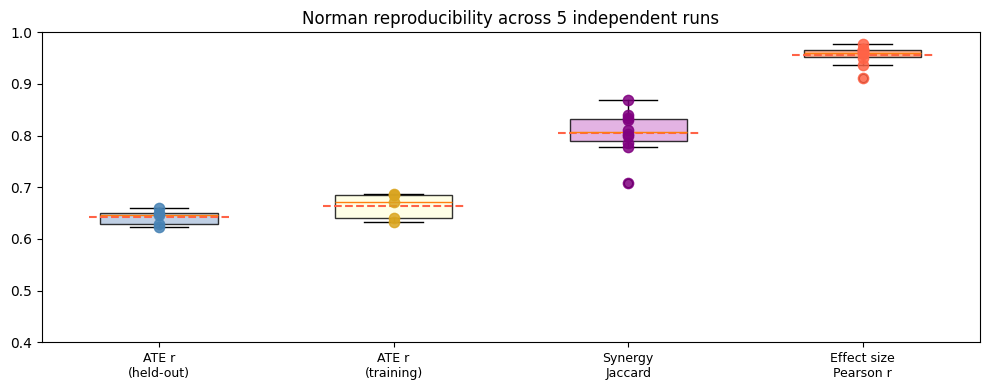

In [22]:
metric_info = [
    ([r['ate_held_r']  for r in run_results], 'ATE r\n(held-out)',      'lightsteelblue', 'steelblue'),
    ([r['ate_train_r'] for r in run_results], 'ATE r\n(training)',      'lightyellow',    'goldenrod'),
    # ([r['n_sig']       for r in run_results], f'# Sig syn\n(q<{SYN_Q_THRESH})', 'lightgreen', 'seagreen'),
    (jaccard_syn,                             'Synergy\nJaccard',       'plum',           'purple'),
    (effect_corrs,                            'Effect size\nPearson r', 'lightsalmon',    'tomato'),
]

fig, ax = plt.subplots(figsize=(10, 4))

for pos, (values, title, fc, sc) in enumerate(metric_info, 1):
    clean = [v for v in values if np.isfinite(v)]
    if not clean:
        continue
    ax.boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=fc, alpha=0.8))
    ax.scatter([pos]*len(clean), clean, color=sc, s=55, zorder=3, alpha=0.85)
    m = np.mean(clean)
    ax.plot([pos - 0.3, pos + 0.3], [m, m], color='tomato', linestyle='--', lw=1.5,
            label=f'mean={m:.3f}')

ax.set_xticks(range(1, len(metric_info) + 1))
ax.set_xticklabels([m[1] for m in metric_info], fontsize=9)
ax.set_title(f'Norman reproducibility across {N_RUNS} independent runs', fontsize=12)
ax.set_ylim(bottom=0.4, top=1)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_boxplots.png', bbox_inches='tight')
plt.show()


## Pairwise heatmaps

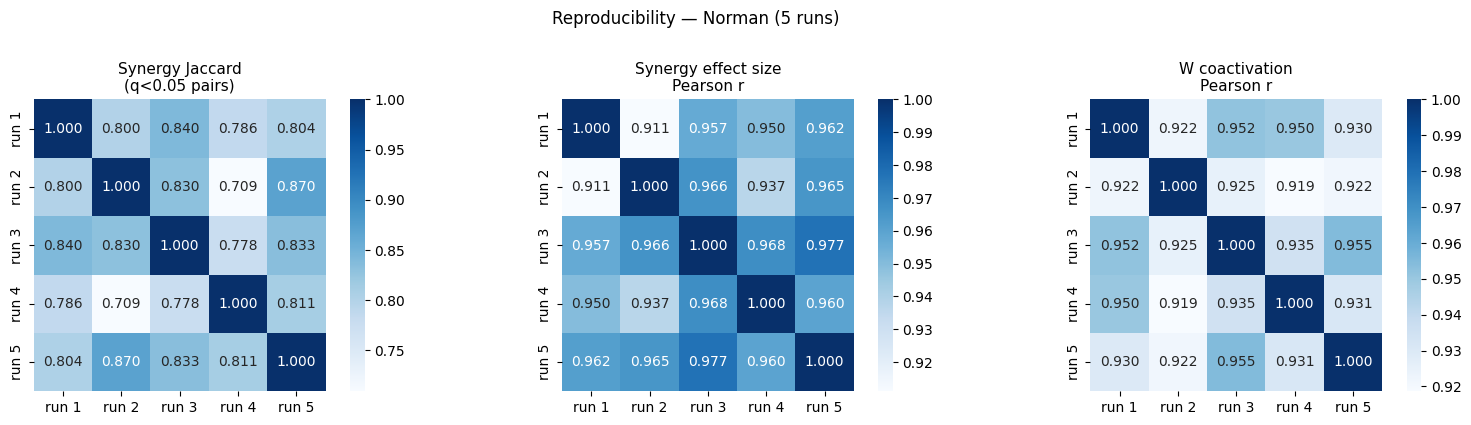

In [27]:
def to_matrix(values, n_runs, pairs, diag=1.0):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, diag)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

# W coactivation: compare W @ W.T across runs (permutation-invariant)
# C[a,b] = dot product of perturbation a and b's gate vectors = how much they share active dims
W_list  = [r['model'].gate(deterministic=True).detach().cpu().numpy() for r in run_results]
C_list  = [W @ W.T for W in W_list]   # (P, P) coactivation matrices

def triu_vals(M):
    idx = np.triu_indices(M.shape[0], k=1)
    return M[idx]

w_corrs = []
for i, j in pairs:
    ci = triu_vals(C_list[i])
    cj = triu_vals(C_list[j])
    r, _ = pearsonr(ci, cj)
    w_corrs.append(r)

J_mat = to_matrix(jaccard_syn, N_RUNS, pairs)
E_mat = to_matrix(effect_corrs, N_RUNS, pairs)
W_mat = to_matrix(w_corrs, N_RUNS, pairs)

run_labels = [f'run {k+1}' for k in range(N_RUNS)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (mat, title) in zip(axes, [
    (J_mat, 'Synergy Jaccard\n(q<0.05 pairs)'),
    (E_mat, 'Synergy effect size\nPearson r'),
    (W_mat, 'W coactivation\nPearson r'),
]):
    off_diag = mat[~np.eye(N_RUNS, dtype=bool)]
    vmin = np.nanmin(off_diag)
    sns.heatmap(mat, ax=ax, annot=True, fmt='.3f',
                vmin=vmin, vmax=1.0, cmap='Blues',
                xticklabels=run_labels, yticklabels=run_labels, square=True)
    ax.set_title(title, fontsize=11)

plt.suptitle(f'Reproducibility — Norman ({N_RUNS} runs)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_heatmaps.png', bbox_inches='tight')
plt.show()


## Synergy frequency bar chart

Shows how many runs each synergy pair was significant in.  
Dark blue = significant in all runs (core); light blue = majority; grey = minority.

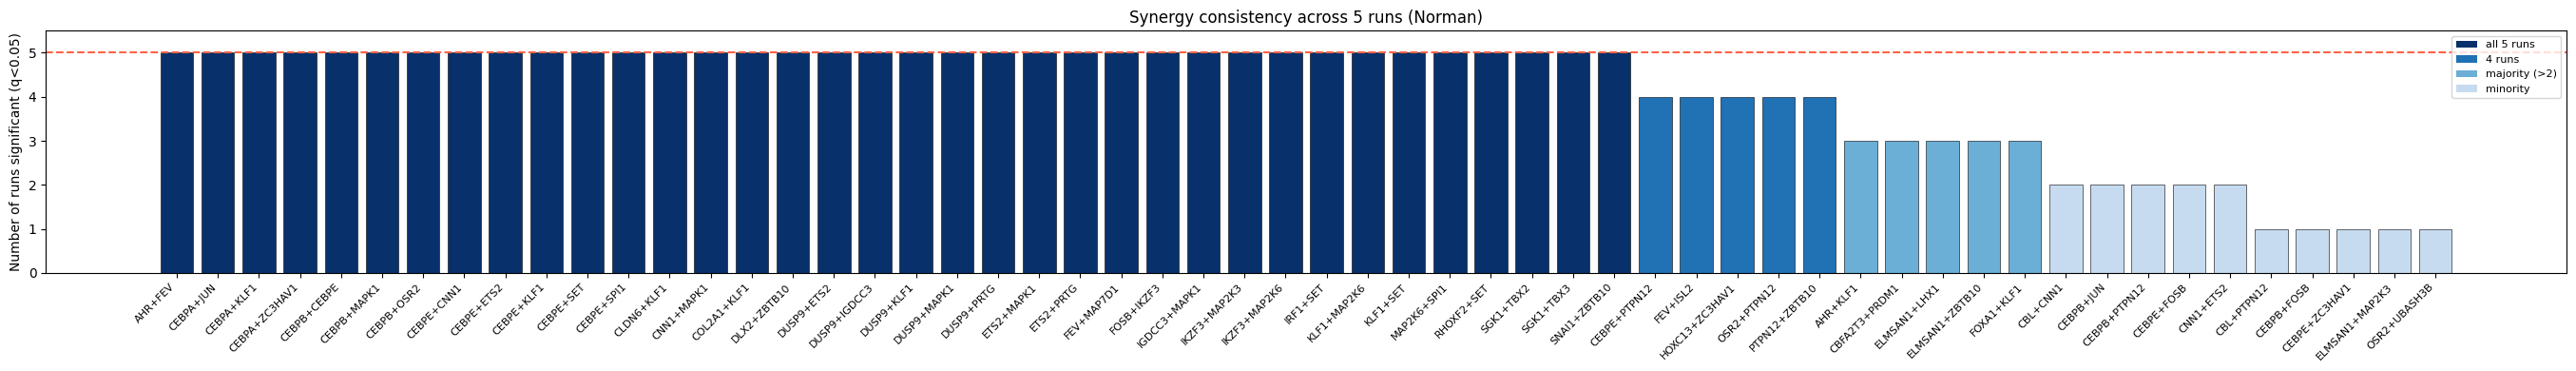

In [15]:
if len(freq_df) == 0:
    print('No synergies found.')
else:
    colors = [
        '#08306b' if n == N_RUNS
        else '#2171b5' if n >= N_RUNS - 1
        else '#6baed6' if n >= N_RUNS // 2 + 1
        else '#c6dbef'
        for n in freq_df['n_runs']
    ]

    fig, ax = plt.subplots(figsize=(max(8, len(freq_df) * 0.45 + 2), 4))
    ax.bar(range(len(freq_df)), freq_df['n_runs'], color=colors,
           edgecolor='k', linewidth=0.4)
    ax.set_xticks(range(len(freq_df)))
    ax.set_xticklabels(freq_df['pair'], rotation=45, ha='right', fontsize=8)
    ax.axhline(N_RUNS, color='tomato', linestyle='--', lw=1.5, label=f'all {N_RUNS} runs')
    ax.set_ylabel(f'Number of runs significant (q<{SYN_Q_THRESH})')
    ax.set_ylim(0, N_RUNS + 0.5)
    ax.set_title(f'Synergy consistency across {N_RUNS} runs (Norman)')
    ax.legend(fontsize=9)

    from matplotlib.patches import Patch
    legend_patches = [
        Patch(fc='#08306b', label=f'all {N_RUNS} runs'),
        Patch(fc='#2171b5', label=f'{N_RUNS-1} runs'),
        Patch(fc='#6baed6', label=f'majority (>{N_RUNS//2})'),
        Patch(fc='#c6dbef', label='minority'),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/figures/synergy_frequency.png', bbox_inches='tight')
    plt.show()

## ATE scatter: held-out combos

Predicted vs observed ATE for the held-out combo perturbations for each run.

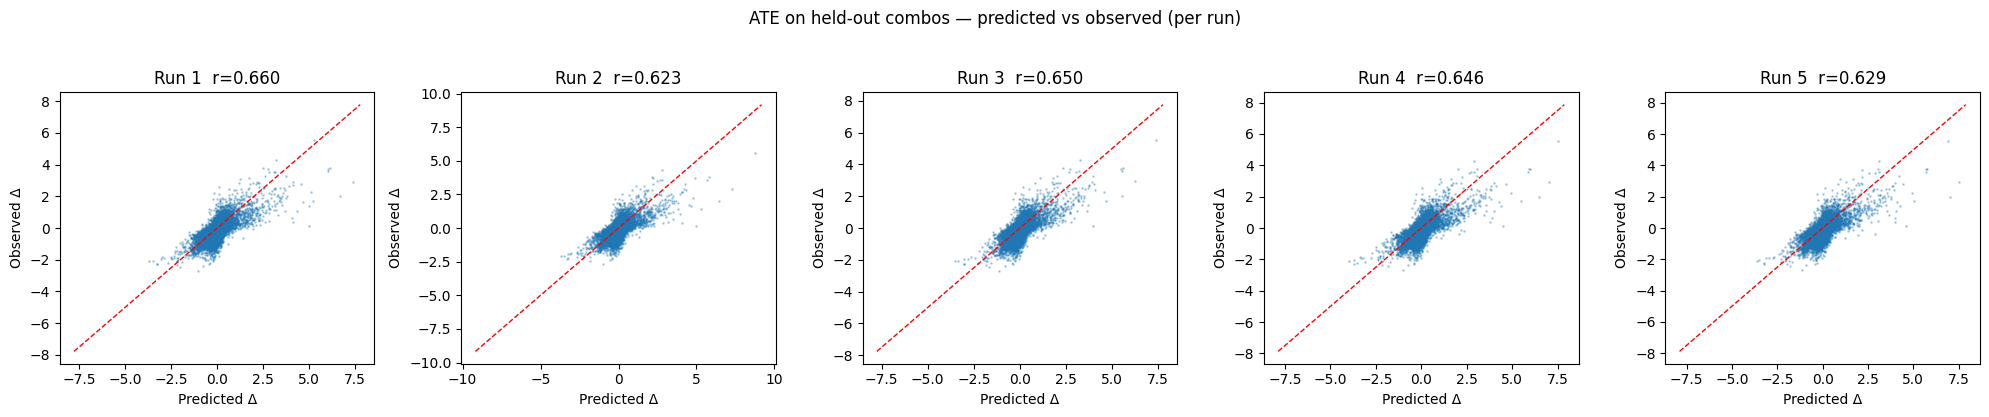

In [16]:
fig, axes = plt.subplots(1, N_RUNS, figsize=(4 * N_RUNS, 4), sharex=False, sharey=False)

obs_df_full = data.uns['treat_effect'].to_df()

for ax, r in zip(axes, run_results):
    hp = r['held_pred']
    if hp is None:
        ax.set_title(f"Run {r['run']+1}\nN/A")
        continue

    common = hp.index.intersection(obs_df_full.index)
    if len(common) == 0:
        ax.set_title(f"Run {r['run']+1}\nN/A")
        continue

    x_flat = hp.loc[common].values.ravel()
    y_flat = obs_df_full.loc[common].values.ravel()
    v      = np.isfinite(x_flat) & np.isfinite(y_flat)

    ax.scatter(x_flat[v], y_flat[v], s=0.8, alpha=0.3, rasterized=True)
    lim = max(np.abs(x_flat[v]).max(), np.abs(y_flat[v]).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlabel('Predicted Δ')
    ax.set_ylabel('Observed Δ')
    ax.set_title(f"Run {r['run']+1}  r={r['ate_held_r']:.3f}")

fig.suptitle('ATE on held-out combos — predicted vs observed (per run)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/ate_holdout_scatter.png', bbox_inches='tight')
plt.show()